In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, date
import os
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [3]:
df_countries = pd.read_csv(f"{OUTPUT_DIR}\\dim_countries.csv")
df_categories = pd.read_csv(f"{OUTPUT_DIR}\\dim_product_categories.csv")
df_products = pd.read_csv(f"{OUTPUT_DIR}\\dim_products.csv")
df_transport_modes = pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
df_ports = pd.read_csv(f"{OUTPUT_DIR}\\dim_ports.csv")
df_suppliers = pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
df_supplier_products = pd.read_csv(f"{OUTPUT_DIR}\\dim_supplier_products.csv")
df_customers = pd.read_csv(f"{OUTPUT_DIR}\\dim_customers.csv")
df_fx = pd.read_csv(f"{OUTPUT_DIR}\\dim_fx_rates.csv")
df_country_risk = pd.read_csv(f"{OUTPUT_DIR}\\dim_country_risk.csv")
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders.csv")
df_po_states = pd.read_csv(f"{OUTPUT_DIR}\\fact_po_state_log.csv")
df_so = pd.read_csv(f"{OUTPUT_DIR}\\fact_sales_orders.csv")
df_audits = pd.read_csv(f"{OUTPUT_DIR}\\fact_supplier_audits.csv")
df_port_congestion = pd.read_csv(f"{OUTPUT_DIR}\\fact_port_congestion.csv")

## Работаем в DF PO

In [4]:
df_po.head(10)

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type
0,1,2019-01-01,23,8,5.0,NaN,NaN,703,10.18,7159.86,...,CIF,L/C,15,23.0,0.0000,0.0,0.415,Delivered,True,underinvoice
1,2,2019-01-03,26,15,3.0,NaN,NaN,401,3.52,1411.52,...,EXW,Wire Transfer,7,10.0,0.0000,0.0,0.822,Delivered,False,NaN
2,3,2019-01-04,10,17,2.0,TRIZM,RUUNS,807,15.02,12121.14,...,EXW,Open Account,39,NaN,0.4367,0.0,0.875,Cancelled,False,NaN
3,4,2019-01-06,23,7,4.0,NaN,NaN,529,70.38,37232.50,...,EXW,L/C,22,28.0,0.0000,0.0,0.415,Delivered,True,underinvoice
4,5,2019-01-06,8,6,4.0,NaN,NaN,749,867.85,650019.65,...,FCA,Wire Transfer,15,14.0,0.0000,0.0,0.824,Delivered,False,NaN
5,6,2019-01-06,15,2,2.0,KRPUS,RUUNS,1468,42.18,61920.24,...,CIF,L/C,37,45.0,0.1878,0.0,0.737,Delivered,False,NaN
6,7,2019-01-07,8,10,4.0,NaN,NaN,1744,84.27,146966.88,...,DDP,Documentary Collection,15,18.0,0.0000,0.0,0.824,Delivered,False,NaN
7,8,2019-01-07,21,21,3.0,NaN,NaN,506,9.27,4690.62,...,DDP,Open Account,6,10.0,0.0000,0.0,0.786,Delivered,False,NaN
8,9,2019-01-07,5,18,1.0,CNSHA,RUUNS,1176,0.86,1011.36,...,DAP,L/C,31,34.0,0.1705,0.0,0.755,Delivered,False,NaN
9,10,2019-01-08,23,7,5.0,NaN,NaN,392,562.96,220680.11,...,FOB,L/C,15,21.0,0.0000,0.0,0.415,Delivered,True,overinvoice


In [5]:
df_po[df_po.duplicated()]

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type
2800,1391,2022-06-17,12,23,3.0,NaN,NaN,1707,1.28,2184.96,...,CIF,Documentary Collection,9,NaN,0.0000,1.0000,0.786,Cancelled,True,phantom
2801,197,2019-06-19,23,8,4.0,NaN,NaN,776,18.91,14674.16,...,EXW,Open Account,22,NaN,0.0000,0.0000,0.415,Cancelled,True,phantom
2802,254,2019-08-10,9,14,5.0,NaN,NaN,1619,2.59,4193.21,...,CIF,Open Account,8,9.0,0.0000,0.0000,0.825,Delivered,False,NaN
2803,2587,2025-07-18,8,8,5.0,NaN,NaN,818,21.13,17284.34,...,EXW,L/C,8,NaN,0.0000,0.0000,0.824,Cancelled,False,NaN
2804,1044,2021-08-15,26,17,4.0,NaN,NaN,286,16.03,4584.58,...,FOB,Open Account,16,19.0,0.0000,0.0000,0.822,Delivered,False,NaN
2805,1491,2022-09-18,23,6,5.0,NaN,NaN,357,181.36,64747.09,...,DAP,Open Account,15,24.0,0.0000,0.5053,0.415,Delivered,True,underinvoice
2806,228,2019-07-19,4,11,5.0,NaN,NaN,164,3.96,649.44,...,DAP,L/C,10,10.0,0.0000,0.0000,0.890,Delivered,False,NaN
2807,260,2019-08-15,11,19,1.0,TRIZM,RUUNS,293,21.88,6410.84,...,CIF,Documentary Collection,32,37.0,0.2352,0.0000,0.894,Delivered,False,NaN
2808,1111,2021-10-07,22,4,1.0,JPYOK,RUUNS,1903,3.61,6869.83,...,FCA,Open Account,29,22.0,0.0584,0.0000,0.940,Delivered,False,NaN
2809,307,2019-09-28,4,12,5.0,NaN,NaN,130,1.54,200.20,...,FOB,Open Account,10,13.0,0.0000,0.0000,0.890,Delivered,False,NaN


In [ ]:
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2822 entries, 0 to 2821
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   po_id                     2822 non-null   int64  
 1   order_date                2822 non-null   object 
 2   supplier_id               2822 non-null   int64  
 3   product_id                2822 non-null   int64  
 4   transport_mode_id         2822 non-null   float64
 5   origin_port_id            1416 non-null   object 
 6   destination_port_id       1503 non-null   object 
 7   quantity                  2822 non-null   int64  
 8   unit_price_usd            2822 non-null   float64
 9   total_value_usd           2822 non-null   float64
 10  currency_code             2822 non-null   object 
 11  fx_rate_to_usd            2822 non-null   float64
 12  total_value_local         2822 non-null   float64
 13  freight_cost_usd          2822 non-null   float64
 14  insuranc

In [16]:
id_cols = ["po_id", "supplier_id", "product_id", "transport_mode_id", "origin_port_id", "destination_port_id"]
time_cols = ["order_date", "expected_delivery_days", "actual_delivery_days", "port_congestion_at_order", "shock_index_at_order"]
fin_cols = ["quantity", "unit_price_usd", "total_value_usd", "total_value_local", "freight_cost_usd", "insurance_cost_usd", "customs_duty_usd"]
pay_cols = ["currency_code", "incoterm", "payment_method"]
suppl_cols = ["supplier_reliability", "final_state", "is_fraud", "fraud_type"]

In [10]:
df_po[id_cols].head(5)

,po_id,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id
0,1,23,8,5.0,NaN,NaN
1,2,26,15,3.0,NaN,NaN
2,3,10,17,2.0,TRIZM,RUUNS
3,4,23,7,4.0,NaN,NaN
4,5,8,6,4.0,NaN,NaN


In [12]:
df_po[["po_id"] + time_cols].head(5)

,po_id,order_date,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order
0,1,2019-01-01,15,23.0,0.0000,0.0
1,2,2019-01-03,7,10.0,0.0000,0.0
2,3,2019-01-04,39,NaN,0.4367,0.0
3,4,2019-01-06,22,28.0,0.0000,0.0
4,5,2019-01-06,15,14.0,0.0000,0.0


In [14]:
df_po[["po_id"]+fin_cols].head(5)

,po_id,quantity,unit_price_usd,total_value_usd,total_value_local,freight_cost_usd,insurance_cost_usd,customs_duty_usd
0,1,703,10.18,7159.86,18791.77,1260.14,60.57,930.56
1,2,401,3.52,1411.52,5498.86,621.07,12.05,274.15
2,3,807,15.02,12121.14,101194.55,1096.73,78.55,2074.67
3,4,529,70.38,37232.50,99496.41,5361.48,321.59,3012.05
4,5,749,867.85,650019.65,553101.72,93602.83,5779.11,125501.49


In [17]:
df_po[["po_id"]+pay_cols].head(5)

,po_id,currency_code,incoterm,payment_method
0,1,BYN,CIF,L/C
1,2,PLN,EXW,Wire Transfer
2,3,TRY,EXW,Open Account
3,4,BYN,EXW,L/C
4,5,EUR,FCA,Wire Transfer


In [18]:
df_po[["po_id"]+suppl_cols].head(5)

,po_id,supplier_reliability,final_state,is_fraud,fraud_type
0,1,0.415,Delivered,True,underinvoice
1,2,0.822,Delivered,False,NaN
2,3,0.875,Cancelled,False,NaN
3,4,0.415,Delivered,True,underinvoice
4,5,0.824,Delivered,False,NaN


# 1) Проверка на дубли

In [5]:
df_po.duplicated().sum()

np.int64(21)

In [6]:
df_po[df_po.duplicated()]

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type
2800,1391,2022-06-17,12,23,3.0,NaN,NaN,1707,1.28,2184.96,...,CIF,Documentary Collection,9,NaN,0.0000,1.0000,0.786,Cancelled,True,phantom
2801,197,2019-06-19,23,8,4.0,NaN,NaN,776,18.91,14674.16,...,EXW,Open Account,22,NaN,0.0000,0.0000,0.415,Cancelled,True,phantom
2802,254,2019-08-10,9,14,5.0,NaN,NaN,1619,2.59,4193.21,...,CIF,Open Account,8,9.0,0.0000,0.0000,0.825,Delivered,False,NaN
2803,2587,2025-07-18,8,8,5.0,NaN,NaN,818,21.13,17284.34,...,EXW,L/C,8,NaN,0.0000,0.0000,0.824,Cancelled,False,NaN
2804,1044,2021-08-15,26,17,4.0,NaN,NaN,286,16.03,4584.58,...,FOB,Open Account,16,19.0,0.0000,0.0000,0.822,Delivered,False,NaN
2805,1491,2022-09-18,23,6,5.0,NaN,NaN,357,181.36,64747.09,...,DAP,Open Account,15,24.0,0.0000,0.5053,0.415,Delivered,True,underinvoice
2806,228,2019-07-19,4,11,5.0,NaN,NaN,164,3.96,649.44,...,DAP,L/C,10,10.0,0.0000,0.0000,0.890,Delivered,False,NaN
2807,260,2019-08-15,11,19,1.0,TRIZM,RUUNS,293,21.88,6410.84,...,CIF,Documentary Collection,32,37.0,0.2352,0.0000,0.894,Delivered,False,NaN
2808,1111,2021-10-07,22,4,1.0,JPYOK,RUUNS,1903,3.61,6869.83,...,FCA,Open Account,29,22.0,0.0584,0.0000,0.940,Delivered,False,NaN
2809,307,2019-09-28,4,12,5.0,NaN,NaN,130,1.54,200.20,...,FOB,Open Account,10,13.0,0.0000,0.0000,0.890,Delivered,False,NaN


# 2. Проверка на пропуски

In [7]:
df_po.isna().any()[df_po.isna().any()]

origin_port_id          True
destination_port_id     True
actual_delivery_days    True
fraud_type              True
dtype: bool

In [21]:
df_po.loc[df_po["fraud_type"].notna(), "is_fraud"].value_counts()

is_fraud
True    441
Name: count, dtype: int64

In [12]:
df_transport_modes

,transport_mode_id,mode_name,mode_description,avg_transit_days,cost_multiplier,delay_probability,uses_port
0,1,Sea FCL,Full Container Load by sea,28,1.0,0.12,True
1,2,Sea LCL,Less than Container Load by sea,35,1.0,0.18,True
2,3,Air Cargo,Air freight,5,5.5,0.05,False
3,4,Rail,Rail freight (incl. Trans-Siberian),14,1.8,0.08,False
4,5,Road,Truck / road freight,7,2.2,0.10,False
5,6,Multimodal,Sea + Rail combination,21,1.3,0.15,True


# 3. Проверка на некорректные значения 


In [22]:
df_po.loc[df_po["transport_mode_id"]*10%10 != 0, :]

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type
69,70,2019-02-25,16,22,18.178278,KRPUS,RUNVS,1471,50.88,74844.48,...,CIF,Open Account,37,47.0,0.2815,0.0000,0.853,Delivered,False,NaN
97,98,2019-03-20,25,13,34.632791,NaN,NaN,1698,1.98,3362.04,...,EXW,L/C,7,NaN,0.0000,0.0000,0.815,Delivered,False,NaN
119,120,2019-04-08,25,14,15.198719,NaN,NaN,763,2.21,1686.23,...,DAP,Wire Transfer,7,NaN,0.0000,0.0000,0.815,Delivered,False,NaN
136,137,2019-04-22,8,8,77.947633,NaN,NaN,1001,21.13,21151.13,...,FOB,Open Account,15,15.0,0.0000,0.0000,0.824,Delivered,False,NaN
137,138,2019-04-23,5,18,14.983486,CNTAO,RUUNS,2002,0.86,1721.72,...,CIF,Open Account,38,52.0,0.2863,0.0000,0.755,Delivered,False,NaN
175,176,2019-06-03,4,14,18.300849,CNSHA,RUNVS,530,2.10,1113.00,...,DAP,Wire Transfer,38,40.0,0.1107,0.0000,0.890,Delivered,False,NaN
217,218,2019-07-09,23,9,9.969431,NaN,RUUNS,472,6.69,3155.46,...,FOB,L/C,36,44.0,0.0000,0.0000,0.415,Delivered,True,overinvoice
312,313,2019-10-01,9,12,26.288873,NaN,NaN,140,1.75,245.00,...,DAP,Documentary Collection,15,15.0,0.0000,0.0000,0.825,Delivered,False,NaN
343,344,2019-10-25,23,8,74.670550,NaN,NaN,829,18.91,15676.39,...,FOB,L/C,22,NaN,0.0000,0.0000,0.415,Cancelled,True,phantom
348,349,2019-10-29,17,19,25.351182,ITGOA,RUNVS,852,23.65,20149.80,...,FOB,Wire Transfer,37,44.0,0.2597,0.0000,0.864,Delivered,False,NaN


In [8]:
df_po[df_po["quantity"]<=0]

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type
1032,1033,2021-08-04,12,25,6.000000,TRIZM,RUNVS,-718,19.19,13777.53,...,CIF,Documentary Collection,25,37.0,0.2982,0.1333,0.786,Delivered,True,overinvoice
1290,1291,2022-03-19,9,14,5.000000,NaN,NaN,-1829,2.59,4737.11,...,CIF,Open Account,8,15.0,0.0000,0.5077,0.825,Delivered,False,NaN
1822,1823,2023-08-09,24,14,5.000000,NaN,NaN,-1377,2.29,3153.33,...,EXW,Documentary Collection,14,15.0,0.0000,0.0000,0.937,Delivered,False,NaN
2059,2060,2024-03-15,13,6,1.000000,INMUN,RUNVS,-511,765.30,391068.30,...,DAP,Documentary Collection,33,46.0,0.4528,0.0000,0.673,Delivered,False,NaN
2462,2463,2025-04-09,26,18,111.646628,NaN,RUUNS,-374,1.12,418.88,...,FOB,L/C,23,NaN,0.0000,0.0000,0.822,Delivered,False,NaN


In [9]:
df_po[df_po["unit_price_usd"]<=0]

,po_id,order_date,supplier_id,product_id,transport_mode_id,origin_port_id,destination_port_id,quantity,unit_price_usd,total_value_usd,...,incoterm,payment_method,expected_delivery_days,actual_delivery_days,port_congestion_at_order,shock_index_at_order,supplier_reliability,final_state,is_fraud,fraud_type


In [32]:
df_po.loc[(df_po["total_value_usd"]*df_po["fx_rate_to_usd"]).round(2) != df_po["total_value_local"].round(2), ["total_value_usd", "fx_rate_to_usd", "total_value_local"]]

,total_value_usd,fx_rate_to_usd,total_value_local
159,6930.00,9.7775,67758.07
466,3042.00,1387.9575,4222166.71
1709,57950.00,8.2971,480816.95
2146,65850.00,7.5773,498965.21
2472,778.75,402.1240,313154.07


In [34]:
df_po.loc[(df_po["quantity"]*df_po["unit_price_usd"]).round(2) != df_po["total_value_usd"], ["quantity", "unit_price_usd", "total_value_usd", "total_value_local"]].head(5)

,quantity,unit_price_usd,total_value_usd,total_value_local
0,703,10.18,7159.86,1.879177e+04
3,529,70.38,37232.50,9.949641e+04
9,392,562.96,220680.11,5.914889e+05
13,1432,23.12,33110.65,7.578274e+08
20,1102,6.30,6943.91,1.781113e+04


# 4. Проверка на выбросы

In [ ]:
df_po[["total_value_usd", "freight_cost_usd", "insurance_cost_usd", "customs_duty_usd"]].describe()

,total_value_usd,freight_cost_usd,insurance_cost_usd,customs_duty_usd
count,2.822000e+03,2822.000000,2822.000000,2822.000000
mean,5.212452e+04,8509.885967,373.582303,5770.437863
std,1.949456e+05,39001.727002,1483.133335,23927.679518
min,1.013800e+02,9.320000,0.400000,9.050000
25%,1.596678e+03,219.257500,11.205000,166.600000
50%,5.551305e+03,743.060000,39.500000,573.525000
75%,2.378042e+04,3170.337500,175.977500,2611.162500
max,2.467868e+06,717414.390000,27474.830000,486910.050000


# 5. Смотрим на корреляцию между переменными и на выбросы

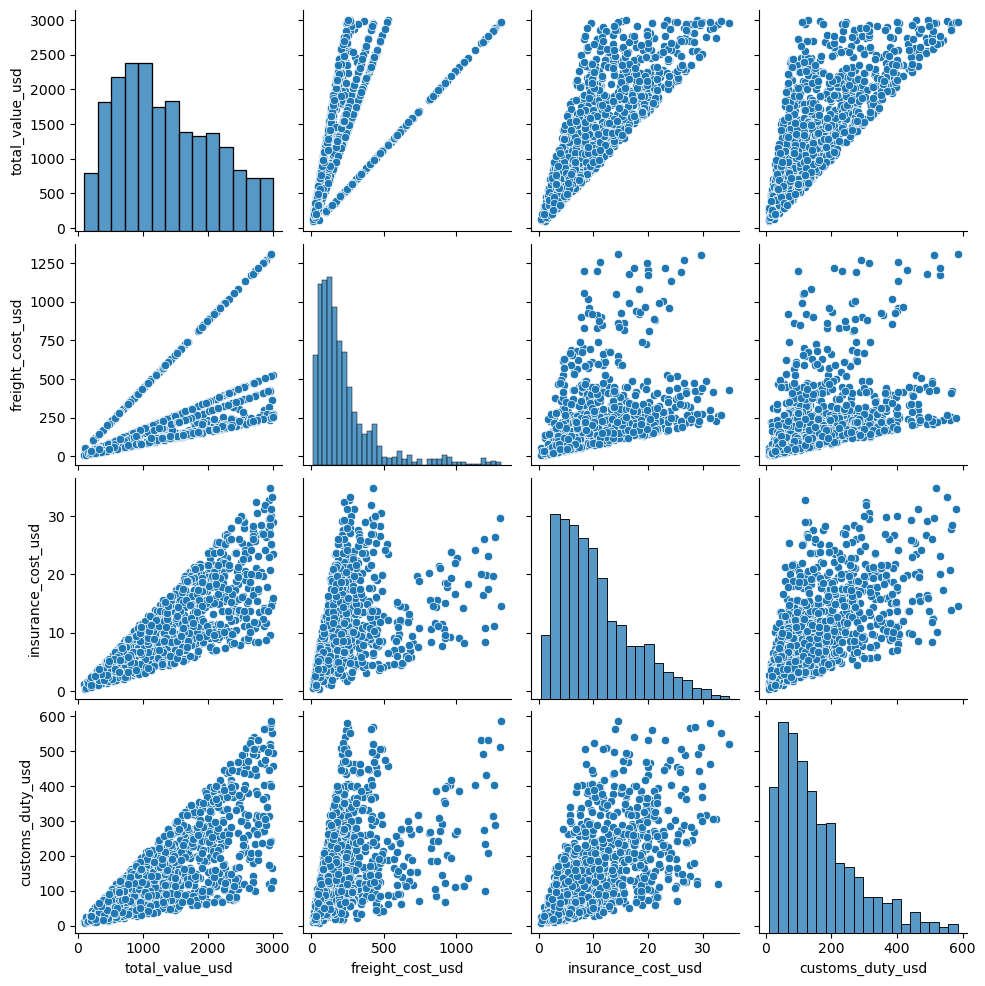

In [40]:
sns.pairplot(df_po.loc[df_po["total_value_usd"]<=3000, ["total_value_usd", "freight_cost_usd", "insurance_cost_usd", "customs_duty_usd"]])

# 6. Проверяем формат Инкотермс

In [95]:
df_po["incoterm"].value_counts()

incoterm
FCA    525
CIF    512
EXW    489
DAP    443
FOB    421
DDP    404
exw      9
cif      5
ddp      5
fob      4
fca      4
dap      1
Name: count, dtype: int64

In [101]:
df_po.loc[~df_po["actual_delivery_days"].isna(), "final_state"].value_counts()

final_state
Delivered    2497
Name: count, dtype: int64

In [ ]:
df_po.loc[df_po["actual_delivery_days"].isna(), "final_state"].value_counts()

final_state
Cancelled    226
Delivered     99
Name: count, dtype: int64

In [105]:
df_po.loc[(df_po["actual_delivery_days"].isna()&(df_po["final_state"]=="Delivered")), "is_fraud"].value_counts()

is_fraud
False    92
True      7
Name: count, dtype: int64

In [108]:
df_po[["port_congestion_at_order", "shock_index_at_order", "supplier_reliability"]].describe()

,port_congestion_at_order,shock_index_at_order,supplier_reliability
count,2822.000000,2822.000000,2822.000000
mean,0.124718,0.103469,0.798258
std,0.180315,0.244828,0.138956
min,0.000000,0.000000,0.363000
25%,0.000000,0.000000,0.786000
50%,0.000000,0.000000,0.824000
75%,0.229200,0.000000,0.889000
max,1.000000,1.000000,0.940000


In [109]:
df_po["final_state"].value_counts()

final_state
Delivered    2596
Cancelled     226
Name: count, dtype: int64

In [110]:
df_po["is_fraud"].value_counts()

is_fraud
False    2381
True      441
Name: count, dtype: int64

In [112]:
df_po["fraud_type"].notna().sum()

np.int64(441)

In [ ]:
df_po["fraud_type"].value_counts()

fraud_type
overinvoice     176
underinvoice    137
phantom         128
Name: count, dtype: int64

# 4. Чистим датасет

In [113]:
# Убираем дубли
df_po = df_po.drop_duplicates()

# Некорректные transport_mode_id заполняем -1
df_po.loc[df_po["transport_mode_id"]*10%10 != 0, "transport_mode_id"] = -1

# Пропуски в origin_port_id и destination_port_id для 1, 2 и 6 transport_mode_id заполняем -2, остальные -1
df_po.loc[((df_po["origin_port_id"].isna())&(df_po["transport_mode_id"].isin([1,2,6]))), "origin_port_id"] = -2
df_po.loc[((df_po["origin_port_id"].isna())&(~df_po["transport_mode_id"].isin([1,2,6]))), "origin_port_id"] = -1
df_po.loc[((df_po["destination_port_id"].isna())&(df_po["transport_mode_id"].isin([1,2,6]))), "destination_port_id"] = -2
df_po.loc[((df_po["destination_port_id"].isna())&(~df_po["transport_mode_id"].isin([1,2,6]))), "destination_port_id"] = -1

# Положительное количество 
df_po = df_po.loc[df_po["quantity"]>0, :]

# Поправляем общую стоимость в USD и в местной валюте
df_po["total_value_usd"] = np.round(df_po["quantity"]*df_po["unit_price_usd"], 2)
df_po["total_value_local"] = np.round(df_po["total_value_usd"] * df_po["fx_rate_to_usd"], 2)

# ИНКОТЕРМС - к строчным
df_po["incoterm"] = df_po["incoterm"].str.capitalize()

# Приводим в порядок формат данных
df_po["order_date"] = pd.to_datetime(df_po["order_date"])
df_po["transport_mode_id"] = df_po["transport_mode_id"].astype(int)
df_po["origin_port_id"] = df_po["transport_mode_id"].astype(int)
df_po["destination_port_id"] = df_po["transport_mode_id"].astype(int)

In [114]:
df_po.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2796 entries, 0 to 2815
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   po_id                     2796 non-null   int64         
 1   order_date                2796 non-null   datetime64[ns]
 2   supplier_id               2796 non-null   int64         
 3   product_id                2796 non-null   int64         
 4   transport_mode_id         2796 non-null   int64         
 5   origin_port_id            2796 non-null   int64         
 6   destination_port_id       2796 non-null   int64         
 7   quantity                  2796 non-null   int64         
 8   unit_price_usd            2796 non-null   float64       
 9   total_value_usd           2796 non-null   float64       
 10  currency_code             2796 non-null   object        
 11  fx_rate_to_usd            2796 non-null   float64       
 12  total_value_local        

In [116]:
df_po.to_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv", index = False)

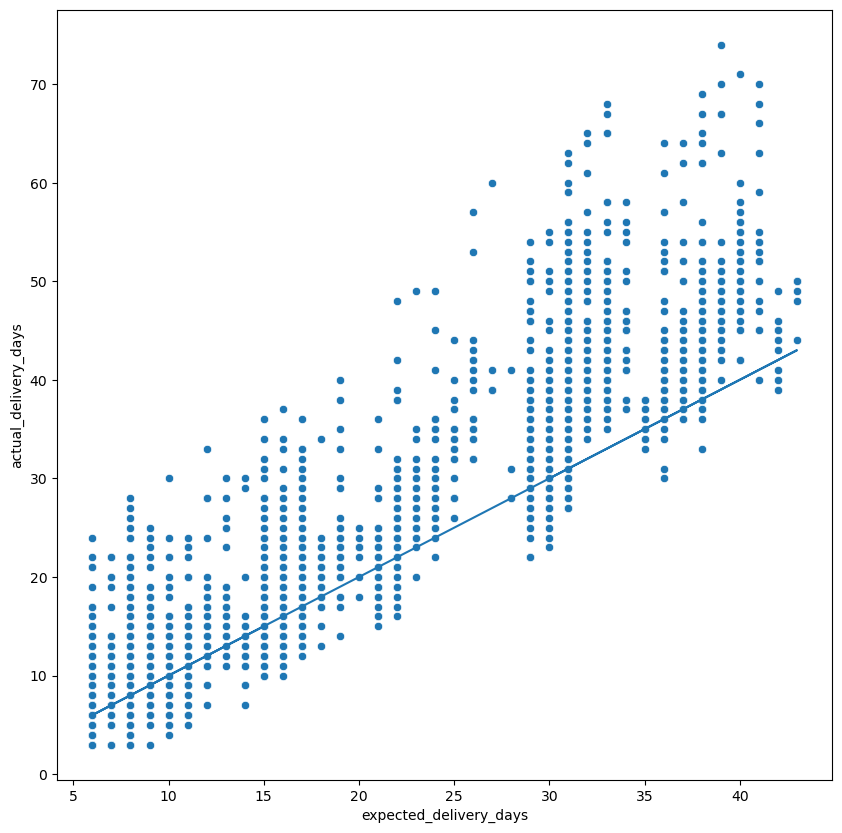

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,1, figsize = (10,10))
sns.scatterplot(x = 'expected_delivery_days', y = 'actual_delivery_days', data = df_po)
ax.plot(df_po['expected_delivery_days'], df_po['expected_delivery_days'])
plt.show()